In [6]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

class FuncModel(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.layer = nn.Linear(in_features, 1) # полносвязный слой: число входов in_features, число нейронов 1

    def forward(self, x):
        return self.layer(x)


torch.manual_seed(1)

epochs = 20 # число эпох обучения
batch_size = 8 # размер батча
N = 6 # порядок модели (N-1)

# формирование обучающей выборки (значений функции)
data_x = torch.arange(-4, 4, 0.01)
data_y = 0.1 * data_x + 0.1 * data_x ** 2 - 0.5 * torch.sin(2 * data_x) + torch.cos(4 * data_x)
data_x.unsqueeze_(-1)
X = torch.cat([data_x ** _n for _n in range(N)], dim=1)
ds = data.TensorDataset(X, data_y)

d_train, d_val = data.random_split(dataset=ds, lengths=[0.8, 0.2]) # разделите выборку ds на две части в пропорции: 80% и 20%
train_data = data.DataLoader(d_train, batch_size=batch_size, shuffle=True)
train_data_val = data.DataLoader(d_val, batch_size=len(d_val), shuffle=False)

model = FuncModel(N)
optimizer = optim.RMSprop(model.parameters(), lr=0.01, weight_decay=10) # создайте оптимизатор RMSprop для модели model с шагом обучения 0.01 и weight_decay=10
loss_func = nn.MSELoss() # сформируйте функцию потерь с помощью класса MSELoss

loss_lst_val = []  # список значений потерь при валидации
loss_lst = []  # список значений потерь при обучении

for _e in range(epochs):
    # переведите модель в режим обучения
    model.train()
    loss_mean = 0
    lm_count = 0

    for x_train, y_train in train_data:
        predict = model(x_train) # вычислите прогноз модели для x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислите потери для predict и y_train

        # выполните один шаг обучения (градиентного спуска)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        lm_count += 1
        loss_mean = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean

    # валидация модели
    # переведите модель в режим эксплуатации
    model.eval()
    x_val, y_val = next(iter(train_data_val))

    with torch.no_grad():
        p = model(x_val) # вычислите прогноз модели для x_val
        loss = loss_func(p.squeeze(), y_val) # вычислите потери для p и y_val
        Q_val = loss.item()

    loss_lst.append(loss_mean)
    loss_lst_val.append(Q_val)

# переведите модель в режим эксплуатации
p = model(X).squeeze() # вычислите прогноз модели по всем данным выборки X
Q = loss_func(p.squeeze(), data_y).item() # вычислите потери с помощью loss_func для p и data_y; значение Q сохраните в виде вещественного числа
Q

0.6522691249847412

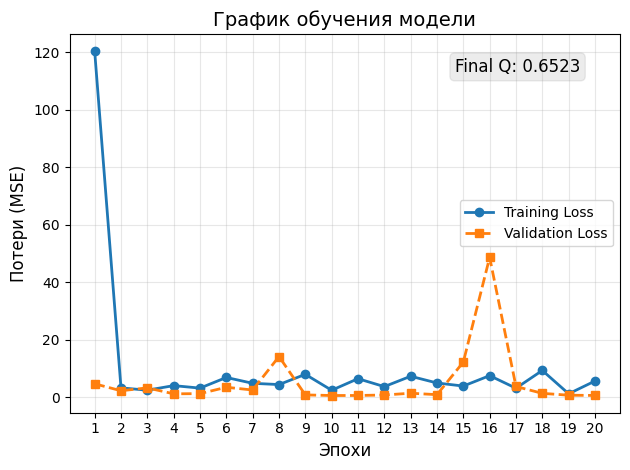

In [17]:
import matplotlib.pyplot as plt

plt.plot(loss_lst, label='Training Loss', marker='o', linestyle='-', linewidth=2)
plt.plot(loss_lst_val, label='Validation Loss', marker='s', linestyle='--', linewidth=2)
plt.title('График обучения модели', fontsize=14)
plt.xlabel('Эпохи', fontsize=12)
plt.ylabel('Потери (MSE)', fontsize=12)
plt.xticks(range(epochs), range(1, epochs+1))  # Нумерация эпох с 1
plt.grid(True, alpha=0.3)
plt.legend()

plt.annotate(f'Final Q: {Q:.4f}', 
             xy=(0.7, 0.9), 
             xycoords='axes fraction',
             fontsize=12,
             bbox=dict(boxstyle="round", alpha=0.15, color='gray'))

plt.tight_layout()
plt.show()

In [18]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели (обязательно до тензора x)
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(13, 32)
        self.layer2 = nn.Linear(32, 16)
        self.layer3 = nn.Linear(16, 3)

        self.dropout = nn.Dropout(p=0.4)

    def forward(self, x):
        y = self.layer1(x).relu()
        y = self.layer2(y).relu()
        y = self.dropout(y)
        y = self.layer3(y)
        return y

model = Model() # здесь создавайте объект модели

x = torch.rand(13)

# здесь продолжайте программу для вычисления predict
predict = model(x)
predict

tensor([-0.2054, -0.0420, -0.3877], grad_fn=<ViewBackward0>)

In [8]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim


# здесь продолжайте программу
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(64, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 10)

        self.dropout1 = nn.Dropout1d(p=0.3)
        self.dropout2 = nn.Dropout1d(p=0.3)

    def forward(self, x):
        y = self.layer1(x).relu()
        y = self.dropout1(y)
        y = self.layer1(y).relu()
        y = self.dropout2(y)
        y = self.layer1(y)
        return y

from sklearn.datasets import load_digits
digits = load_digits()

_global_var_data_x = digits.data # (1797, 64)
_global_var_target = digits.target # (1797, 1)

data_x = torch.tensor(_global_var_data_x, dtype=torch.float32)
data_y = torch.tensor(_global_var_target, dtype=torch.int64)

model = Model()

ds = data.TensorDataset(data_x, data_y)
d_train, d_test = data.random_split(dataset=ds, lengths=[0.7, 0.3])

train_data = data.DataLoader(d_train, batch_size=16, shuffle=True)
train_data_val = data.DataLoader(d_test, batch_size=len(d_test))

epochs = 2
lr = 0.01
weight_decay = 0.1

optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
loss_func = nn.CrossEntropyLoss()

model.train()

for _e in range(epochs):
    for x_train, y_train in train_data:
        predict = model(x_train)
        loss = loss_func(predict.squeeze(), y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

model.eval()

p = 0

for x_val, y_val in train_data_val:
    predict = model(x_val)
    p += (predict.argmax(dim=1) == y_val).sum().item()

Q = p / len(d_test)
Q

0.8775510204081632